# Homework 3: ConvNets For Land Classification

Connecting my GitHub repo.

In [1]:
import os

repo_path = "/content/computational_methods_course"

if not os.path.exists(repo_path):
    !git clone https://github.com/jackeflan/computational_methods_course.git

%cd /content/computational_methods_course
!git pull

Cloning into 'computational_methods_course'...
remote: Enumerating objects: 854, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 854 (delta 77), reused 67 (delta 67), pack-reused 764 (from 1)
Receiving objects: 100% (854/854), 78.92 MiB | 12.91 MiB/s, done.
Resolving deltas: 100% (128/128), done.
Updating files: 100% (605/605), done.
/content/computational_methods_course
Already up to date.


Installing the dataset lib

In [ ]:
!pip install -q datasets

Importing necessary packages/libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.models as models

from datasets import load_dataset


Loading the specific dataset

In [ ]:
ds = load_dataset("nikolkoo/SatelliteSegmentation")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/93.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/790 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 790
    })
})


Loading one training example and visualizing it next to its rgb mask.

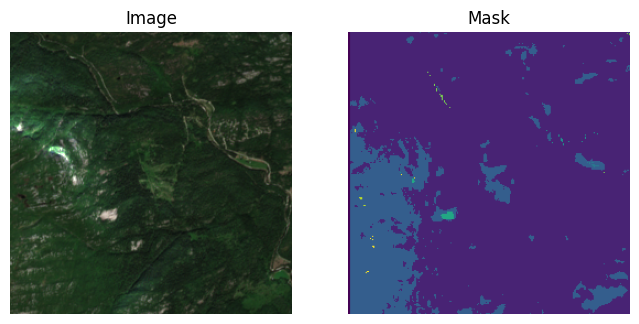

In [ ]:
sample = ds["train"][0]
image = sample["image"]
mask = sample["mask"]

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")
plt.show()

Now lets find the class values, remap them to contiguous indices then find the total number of classes.

In [ ]:
# FIND CLASS CODES
all_codes = set()
for ex in ds["train"]:
    all_codes.update(np.unique(np.array(ex["mask"])))

all_codes = sorted(all_codes)
print("Raw codes:", all_codes)

raw_to_contig = {raw: i for i, raw in enumerate(all_codes)}
contig_to_raw = {i: raw for raw, i in raw_to_contig.items()}

num_classes = len(all_codes)
print("Num classes:", num_classes)

Raw codes: [np.uint8(0), np.uint8(10), np.uint8(20), np.uint8(30), np.uint8(40), np.uint8(50), np.uint8(60), np.uint8(70), np.uint8(80), np.uint8(90), np.uint8(100)]
Num classes: 11


Now we've computed how many pixels are in each class. Lets plot their densities...

Class fractions: [2.07674051e-04 7.06167834e-01 3.14060646e-05 9.27370675e-02
 7.38155896e-02 3.77754501e-02 1.78373313e-03 9.46431220e-07
 8.60755244e-02 7.83316697e-04 6.21457643e-04]


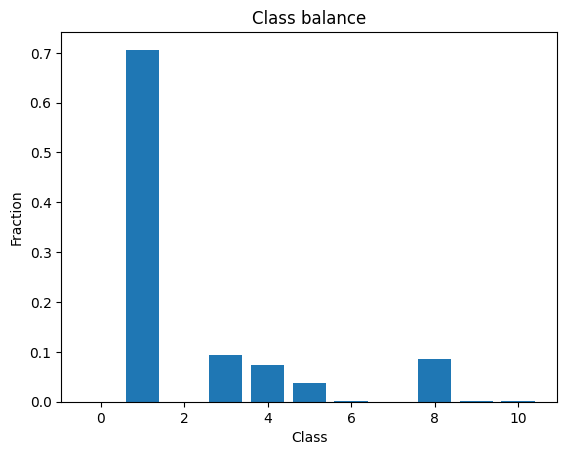

In [ ]:
# CLASS BALANCE
class_counts = np.zeros(num_classes)

for ex in ds["train"]:
    m = np.array(ex["mask"])
    m = np.vectorize(raw_to_contig.get)(m)
    vals, counts = np.unique(m, return_counts=True)
    class_counts[vals] += counts

total_pixels = class_counts.sum()
class_fractions = class_counts / total_pixels

print("Class fractions:", class_fractions)

plt.figure()
plt.bar(range(num_classes), class_fractions)
plt.title("Class balance")
plt.xlabel("Class")
plt.ylabel("Fraction")
plt.show()

Oooooo... looks like class 1 dominates. I first tried to train this model without applying the sqrt to the inverse-frequency weighting and had some awful results. Then I applied the sqrt which dulled some of the extremes and improved the model performance.

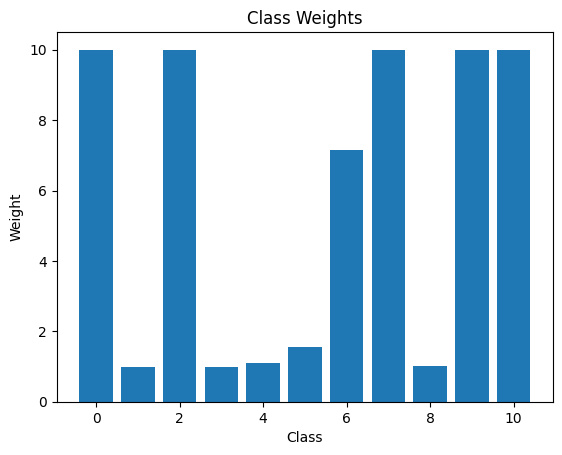

In [ ]:
# CLASS WEIGHTS
class_weights = total_pixels / (num_classes * class_counts)
class_weights = np.sqrt(class_weights)
class_weights = np.clip(class_weights, 1.0, 10.0)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

#PREVIOUS APPROACH
#class_weights = total_pixels / (num_classes * class_counts)
#class_weights = np.clip(class_weights, 0, 50)
#class_weights = torch.tensor(class_weights, dtype=torch.float32)
#print("Class weights:", class_weights)

plt.figure()
plt.bar(range(num_classes), class_weights.cpu().numpy())
plt.title("Class Weights")
plt.xlabel("Class")
plt.ylabel("Weight")
plt.show()

I'm sure I could continue to doctor this but, it looks aight to me... Now time to pull some samples and plot them.

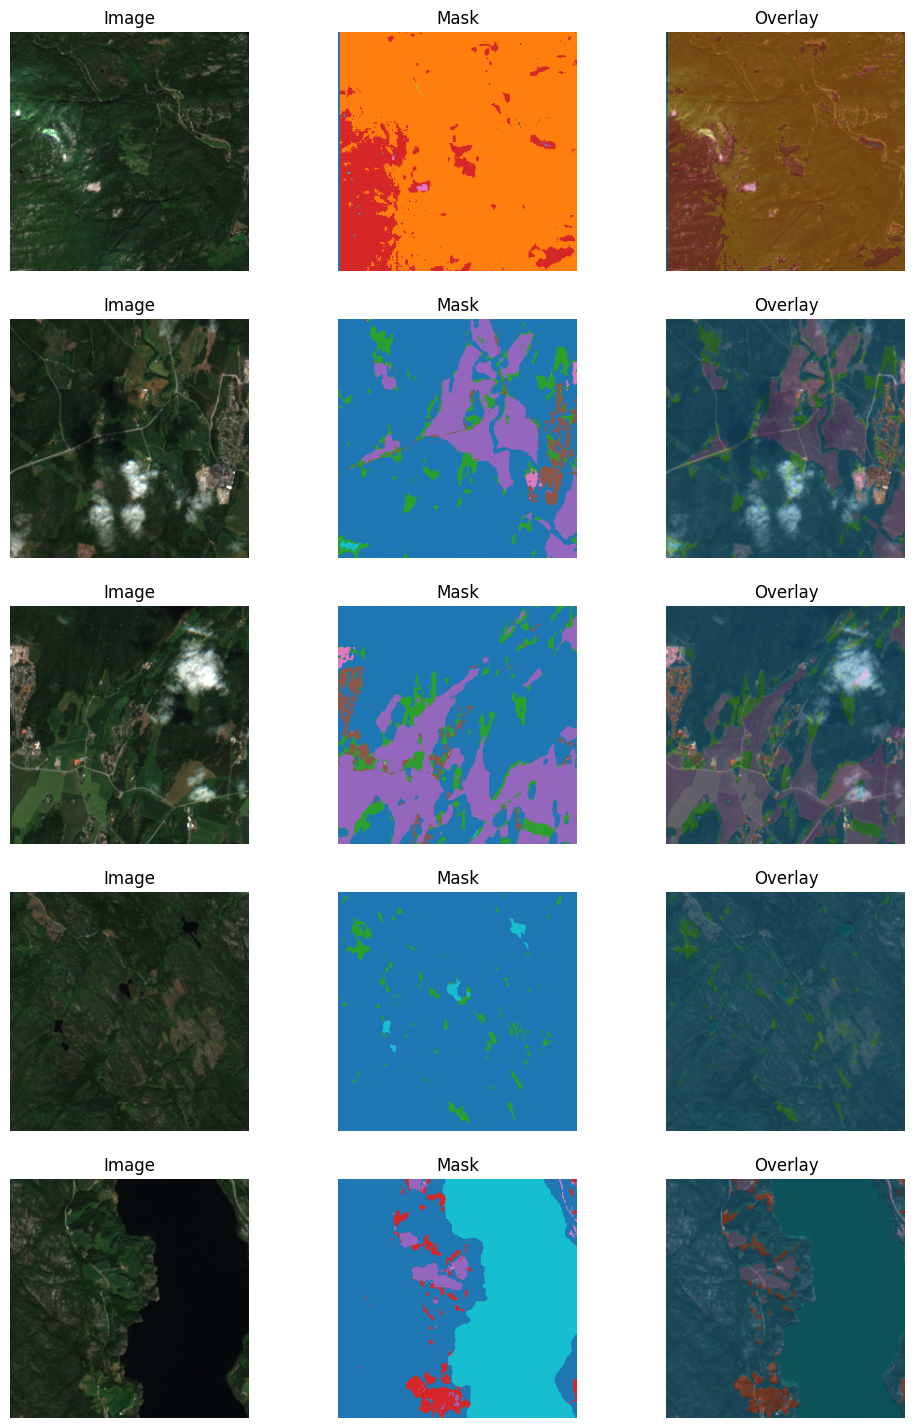

In [ ]:
# VISUALIZATION
cmap = plt.get_cmap("tab10", num_classes)

fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for i in range(5):
    ex = ds["train"][i]
    img = np.array(ex["image"])
    m = np.vectorize(raw_to_contig.get)(np.array(ex["mask"]))

    axes[i,0].imshow(img)
    axes[i,0].set_title("Image")
    axes[i,0].axis("off")

    axes[i,1].imshow(m, cmap=cmap)
    axes[i,1].set_title("Mask")
    axes[i,1].axis("off")

    axes[i,2].imshow(img)
    axes[i,2].imshow(m, cmap=cmap, alpha=0.4)
    axes[i,2].set_title("Overlay")
    axes[i,2].axis("off")

plt.show()

Let's prep the functions to build the PyTorch dataset... Let's load the images and masks, resize, normalize, then remap the mask labels to the contiguous classes.

In [ ]:
# DATASET CLASS (128x128)
class SatelliteDataset(Dataset):
    def __init__(self, hf_dataset, raw_to_contig, image_size=(128,128)):
        self.ds = hf_dataset
        self.map = raw_to_contig
        self.size = image_size

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]

        image = ex["image"].convert("RGB")
        mask = ex["mask"]

        image = TF.resize(image, self.size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.size, interpolation=InterpolationMode.NEAREST)

        image = TF.to_tensor(image)

        image = TF.normalize(image,
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225])

        mask = np.array(mask)
        mask = np.vectorize(self.map.get)(mask)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

... and build it...

In [ ]:
# BUILD DATASETS
full_dataset = SatelliteDataset(ds["train"], raw_to_contig)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


... and batch it...

In [ ]:
# DATALOADER
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Now here's the sad part... I trained my model too many times and ran out of free GPU usage on Colab. Unfortunatley, I was unable to train my model again and will resort to memory for the discussion.

In [ ]:
# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


Really tried my best here to build a Unet with the DoubleConv, but ultimately failed and gave up. I have long deleted the code and may need to revisit this in research.

In [ ]:
# MODEL (RESNET)
model = models.segmentation.fcn_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(512, num_classes, kernel_size=1)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:01<00:00, 107MB/s] 


Classic cross entropy loss and adam optimizer.

In [ ]:
# LOSS + OPTIM
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

The define the confusion matrix to see how often we predict class j with true class i. We also define the finction to compute the intersections over union (IoU).

In [ ]:
# METRICS
def conf_matrix(pred, target, n):
    pred = pred.view(-1)
    target = target.view(-1)

    mask = (target >= 0) & (target < n)

    hist = torch.bincount(
        n * target[mask] + pred[mask],
        minlength=n**2
    ).reshape(n,n)

    return hist

def compute_ious(conf):
    ious = []
    for c in range(conf.shape[0]):
        tp = conf[c,c]
        fp = conf[:,c].sum() - tp
        fn = conf[c,:].sum() - tp
        denom = tp + fp + fn
        ious.append((tp/denom).item() if denom > 0 else 0)
    return np.array(ious)

Then we define a training function that evaluates it, while saving the best-performing model based on validation mIoU.

In [ ]:
# TRAIN LOOP
def train(model, epochs=20):
    train_losses, val_losses, val_mious = [], [], []

    best = -1
    best_state = None

    for e in range(epochs):

        model.train()
        t_loss = 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)["out"]
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

            t_loss += loss.item()*x.size(0)

        t_loss /= len(train_loader.dataset)

        model.eval()
        v_loss = 0
        conf = torch.zeros((num_classes,num_classes), device=device)

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)

                out = model(x)["out"]
                loss = criterion(out,y)

                pred = torch.argmax(out,1)

                v_loss += loss.item()*x.size(0)
                conf += conf_matrix(pred,y,num_classes)

        v_loss /= len(val_loader.dataset)
        ious = compute_ious(conf)
        miou = ious.mean()

        train_losses.append(t_loss)
        val_losses.append(v_loss)
        val_mious.append(miou)

        if miou > best:
            best = miou
            best_state = model.state_dict()

        print(f"Epoch {e+1}/{epochs} | train={t_loss:.3f} | val={v_loss:.3f} | mIoU={miou:.3f}")

    model.load_state_dict(best_state)

    return train_losses, val_losses, val_mious, ious

... train it...

In [ ]:
# TRAIN
train_losses, val_losses, val_mious, final_ious = train(model)

Epoch 1/20 | train=1.566 | val=1.233 | mIoU=0.194
Epoch 2/20 | train=1.055 | val=0.943 | mIoU=0.220
Epoch 3/20 | train=0.867 | val=0.764 | mIoU=0.250
Epoch 4/20 | train=0.735 | val=0.686 | mIoU=0.275
Epoch 5/20 | train=0.657 | val=0.654 | mIoU=0.261
Epoch 6/20 | train=0.600 | val=0.606 | mIoU=0.280
Epoch 7/20 | train=0.567 | val=0.575 | mIoU=0.287
Epoch 8/20 | train=0.531 | val=0.560 | mIoU=0.286


... and plot the loss vs epoch and mIoU...

In [ ]:
# PLOTS
epochs = np.arange(1,len(train_losses)+1)

plt.plot(epochs, train_losses, label="train")
plt.plot(epochs, val_losses, label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(epochs, val_mious)
plt.title("mIoU")
plt.show()

(Going from memory here)
The validation curve used to sit far above the training curve before the sqrt softening of inverse-frequency extremes. The validation curve does not seem to overfit now as it drops significantly closer to the training curve looks pretty good, but never as good as Aldo's. You can see the mIoUs also increase with a decrease in loss.

Now let's plot each class IoU to see who's performing the best. To be honest, I forgot what this plot looks like :(

In [ ]:
plt.bar(range(num_classes), final_ious)
plt.axhline(final_ious.mean())
plt.title("Class IoU")
plt.show()

Now let's unpack, unnormalize, and plot our data... Picture vs ground truth vs model prediction.

In [ ]:
# QUALITATIVE RESULTS
def unnormalize(img):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    img = img.cpu()*std + mean
    return img.permute(1,2,0).numpy()

model.eval()

fig, axes = plt.subplots(4,3, figsize=(12,12))

for i in range(4):
    x,y = val_dataset[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))["out"]
        pred = torch.argmax(pred,1).squeeze().cpu().numpy()

    y = y.numpy()

    axes[i,0].imshow(unnormalize(x))
    axes[i,0].set_title("Input")
    axes[i,0].axis("off")

    axes[i,1].imshow(y)
    axes[i,1].set_title("Ground truth")
    axes[i,1].axis("off")

    axes[i,2].imshow(pred)
    axes[i,2].set_title("Prediction")
    axes[i,2].axis("off")

plt.show()

You can see it actually does quite a good job at classifying overall/average behavior, but it looks to me that it is missing the one-off and sharp contrast cells. I think we might be loosing a bit of the high-frequency data, maybe a (propperly designed) Unet can fix this problem. We also, may be losing some data from the overrepresentation of some classes over others... We can fix this by better weighting these in the loss.

# Reflection

Honestly, pixel accuracy would be pretty misleading here because the dataset is super skewed, with class 1 dominating most of the pixels. A model could just predict that class most of the time and still look “good” in terms of accuracy, even if it completely misses the rare classes. IoU fixes that by actually penalizing both missed regions and over-predicted regions, so it gives a much more honest picture of how well each class is segmented. As for the pretrained encoder, I’d expect it to perform better than training from scratch because it already knows how to detect useful visual features like edges, textures, and shapes. Even though satellite imagery is a different domain, those low-level features still transfer pretty well, so the model doesn’t have to learn everything from zero.